In [1]:
# Cell 1: Installation
# !pip install diffusers transformers accelerate torch torchvision Pillow

In [1]:
# Cell 2: Imports and device setup
import torch
from diffusers import StableDiffusionPipeline
from PIL import Image
import os
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
dtype = torch.float16 if device == 'cuda' else torch.float32
print(f'Using device: {device}')

C:\Users\jc301368\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\jc301368\AppData\Roaming\Python\Python312\site-packages\diffusers\models\transformers\transformer_kandinsky.py:168: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)
C:\Users\jc301368\AppData\Roaming\Python\Python312\site-packages\diffusers\models\transformers\transformer_kandinsky.py:272: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)


Using device: cpu


In [2]:
# Cell 3: Model loading
# Using runwayml/stable-diffusion-v1-5 -- free and widely available on Hugging Face.
# If you get a 401 error, create a free account at https://huggingface.co,
# generate a token at https://huggingface.co/settings/tokens, then run:
#   from huggingface_hub import login; login(token='YOUR_TOKEN_HERE')

MODEL_ID = 'runwayml/stable-diffusion-v1-5'

pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=dtype,
    safety_checker=None,
    requires_safety_checker=False,
)
pipe = pipe.to(device)

if device == 'cpu':
    pipe.enable_attention_slicing()

print('Model loaded successfully.')

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
C:\Users\jc301368\AppData\Roaming\Python\Python312\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\jc301368\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mod

Model loaded successfully.


In [3]:
# Cell 4: Prompt definition
BASE_STYLE = (
    'semi-realistic animated film style, cinematic lighting, high detail, '
    '16:9 wide composition, no text, no watermarks, photorealistic rendering, '
    'small cute round white exploration robot with glowing blue sensors, '
    'overgrown abandoned city, crumbling concrete buildings covered in vines'
)

NEGATIVE_PROMPT = (
    'text, watermark, signature, blurry, low quality, deformed, ugly, '
    'cartoon, anime, extra limbs, multiple robots'
)

scene_prompts = [
    # Scene 1: Establishing shot
    (
        'Scene establishing shot: small cute round white exploration robot enters an overgrown abandoned city at sunset, '
        'warm golden hour light, long shadows, ruins of skyscrapers covered in ivy and moss, dramatic sky with orange and purple clouds, '
        + BASE_STYLE
    ),
    # Scene 2: Investigation
    (
        'Scene investigation: small cute round white exploration robot scanning surroundings with a bright blue light beam, '
        'blue scanning ray illuminates dusty air and rubble, close-up cinematic angle, mist rising from cracked ground, '
        'abandoned city street at dusk, ' + BASE_STYLE
    ),
    # Scene 3: Discovery
    (
        'Scene discovery: small cute round white exploration robot discovers a glowing bioluminescent plant growing through cracked concrete, '
        'plant emits soft cyan and green light, robot stares in awe, dark ruined environment, dramatic contrast between darkness and plant glow, '
        + BASE_STYLE
    ),
    # Scene 4: Interaction
    (
        'Scene interaction: small cute round white exploration robot gently touches a glowing bioluminescent plant with its robotic arm, '
        'plant glow intensifies brilliantly illuminating surrounding ruins, magical light explosion of cyan and white, '
        'emotional cinematic moment, ruins bathed in warm glow, ' + BASE_STYLE
    ),
]

print('Prompts defined for 4 scenes.')
for i, p in enumerate(scene_prompts, 1):
    print(f'Scene {i}: {p[:100]}...')

Prompts defined for 4 scenes.
Scene 1: Scene establishing shot: small cute round white exploration robot enters an overgrown abandoned city...
Scene 2: Scene investigation: small cute round white exploration robot scanning surroundings with a bright bl...
Scene 3: Scene discovery: small cute round white exploration robot discovers a glowing bioluminescent plant g...
Scene 4: Scene interaction: small cute round white exploration robot gently touches a glowing bioluminescent ...


In [4]:
# Cell 5: Image generation loop
SEED = 42
NUM_INFERENCE_STEPS = 30  # Reduce to 20 for faster CPU runs
GUIDANCE_SCALE = 7.5
WIDTH, HEIGHT = 768, 432  # 16:9 aspect ratio

generated_images = []

for i, prompt in enumerate(scene_prompts, 1):
    print(f'Generating scene {i}/4...')
    generator = torch.Generator(device=device).manual_seed(SEED)

    result = pipe(
        prompt=prompt,
        negative_prompt=NEGATIVE_PROMPT,
        width=WIDTH,
        height=HEIGHT,
        num_inference_steps=NUM_INFERENCE_STEPS,
        guidance_scale=GUIDANCE_SCALE,
        generator=generator,
    )

    img = result.images[0]
    generated_images.append(img)
    print(f'Scene {i} generated.')

print('All 4 scenes generated successfully!')

Token indices sequence length is longer than the specified maximum sequence length for this model (100 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['rendering , small cute round white exploration robot with glowing blue sensors , overgrown abandoned city , crumbling concrete buildings covered in vines']


Generating scene 1/4...


100%|██████████| 30/30 [10:51<00:00, 21.71s/it]
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['rendering , small cute round white exploration robot with glowing blue sensors , overgrown abandoned city , crumbling concrete buildings covered in vines']


Scene 1 generated.
Generating scene 2/4...


100%|██████████| 30/30 [48:56<00:00, 97.87s/it]    
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['marks , photorealistic rendering , small cute round white exploration robot with glowing blue sensors , overgrown abandoned city , crumbling concrete buildings covered in vines']


Scene 2 generated.
Generating scene 3/4...


100%|██████████| 30/30 [06:19<00:00, 12.64s/it]
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: [', no watermarks , photorealistic rendering , small cute round white exploration robot with glowing blue sensors , overgrown abandoned city , crumbling concrete buildings covered in vines']


Scene 3 generated.
Generating scene 4/4...


100%|██████████| 30/30 [07:26<00:00, 14.89s/it]


Scene 4 generated.
All 4 scenes generated successfully!


In [5]:
# Cell 6: Save outputs
output_dir = os.getcwd()
filenames = ['scene_1.png', 'scene_2.png', 'scene_3.png', 'scene_4.png']

for fname, img in zip(filenames, generated_images):
    path = os.path.join(output_dir, fname)
    img.save(path)
    print(f'Saved: {path}')

print('All scenes saved to disk.')

Saved: c:\Users\jc301368\OneDrive - Shepherd Center\Documents\School\Computer Vision\Computer-Vision\Module 6\scene_1.png
Saved: c:\Users\jc301368\OneDrive - Shepherd Center\Documents\School\Computer Vision\Computer-Vision\Module 6\scene_2.png
Saved: c:\Users\jc301368\OneDrive - Shepherd Center\Documents\School\Computer Vision\Computer-Vision\Module 6\scene_3.png
Saved: c:\Users\jc301368\OneDrive - Shepherd Center\Documents\School\Computer Vision\Computer-Vision\Module 6\scene_4.png
All scenes saved to disk.


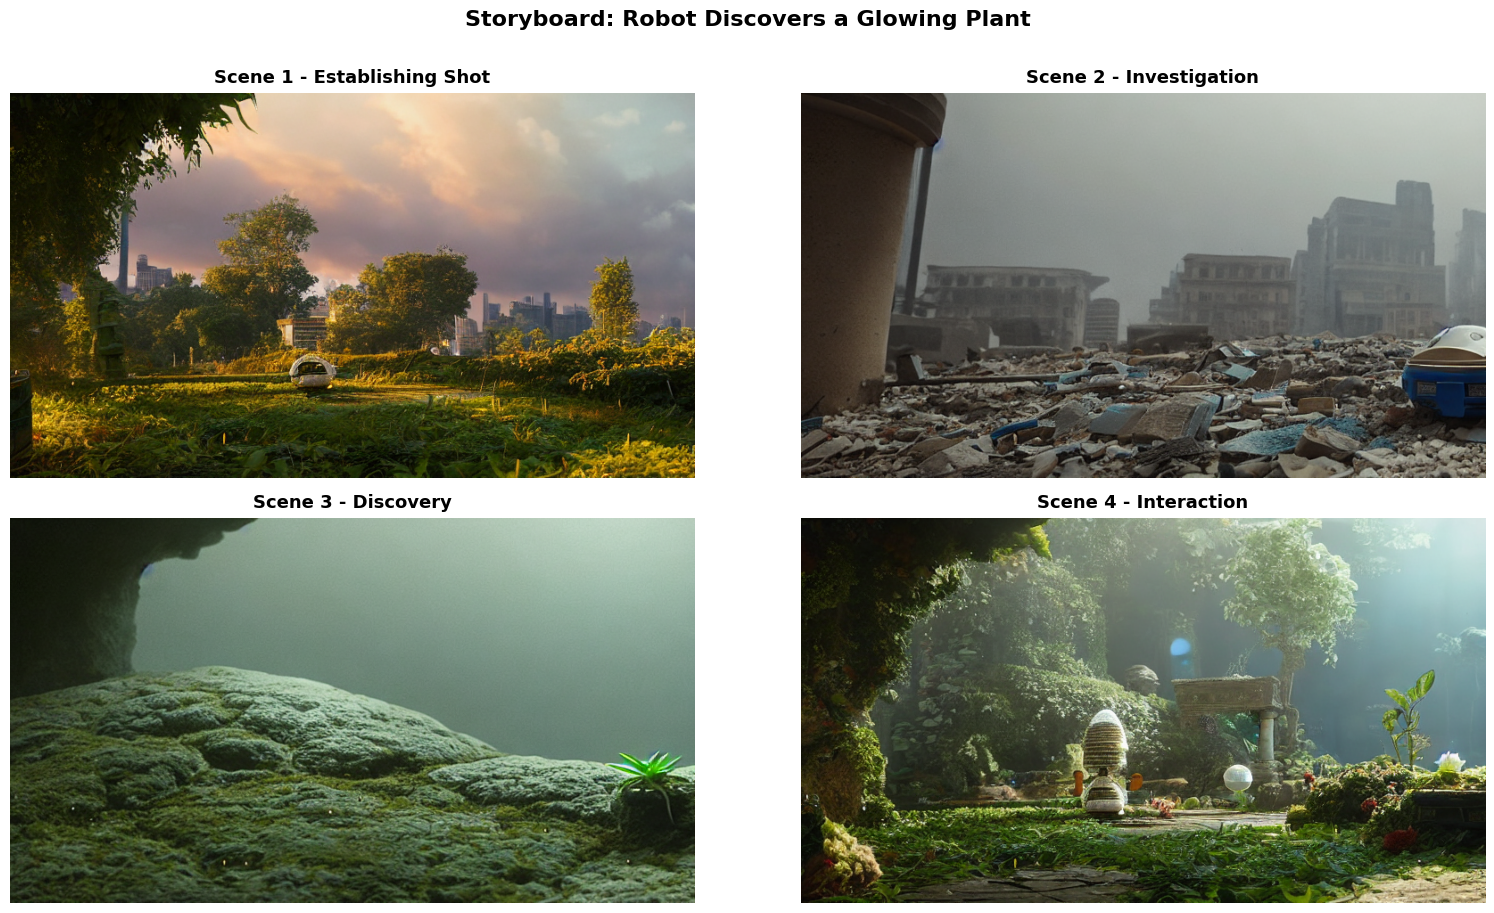

Preview saved as storyboard_preview.png


In [6]:
# Cell 7: Quick preview
scene_titles = [
    'Scene 1 - Establishing Shot',
    'Scene 2 - Investigation',
    'Scene 3 - Discovery',
    'Scene 4 - Interaction',
]

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

for ax, img, title in zip(axes, generated_images, scene_titles):
    ax.imshow(img)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=8)
    ax.axis('off')

plt.suptitle('Storyboard: Robot Discovers a Glowing Plant', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('storyboard_preview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Preview saved as storyboard_preview.png')

In [7]:
# Cell 8: Install video generation dependencies
# Stable Video Diffusion (SVD) takes each storyboard image and generates
# ~4 seconds of real AI motion video from it -- fully free via Hugging Face.
!pip install diffusers transformers accelerate imageio imageio-ffmpeg opencv-python --quiet

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Program Files\Python313\python.exe -m pip install --upgrade pip


In [8]:
# Cell 9: Load Stable Video Diffusion (img2vid)
# Model: stabilityai/stable-video-diffusion-img2vid-xt (free on HF)
# Requirements: ~10GB VRAM on GPU. On CPU this will be very slow (30-60 min/scene).
# If you get a 401 error, login with: from huggingface_hub import login; login('YOUR_TOKEN')

from diffusers import StableVideoDiffusionPipeline
from diffusers.utils import export_to_video
import torch
from PIL import Image
import gc

SVD_MODEL_ID = 'stabilityai/stable-video-diffusion-img2vid-xt'

# Free up memory from the image generation pipeline
del pipe
gc.collect()
if device == 'cuda':
    torch.cuda.empty_cache()

svd_pipe = StableVideoDiffusionPipeline.from_pretrained(
    SVD_MODEL_ID,
    torch_dtype=torch.float16 if device == 'cuda' else torch.float32,
    variant='fp16' if device == 'cuda' else None,
)
svd_pipe = svd_pipe.to(device)
svd_pipe.enable_attention_slicing()  # Reduce memory usage on any hardware

print('Stable Video Diffusion loaded successfully.')

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
C:\Users\jc301368\AppData\Roaming\Python\Python312\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\jc301368\.cache\huggingface\hub\models--stabilityai--stable-video-diffusion-img2vid-xt. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activat

Stable Video Diffusion loaded successfully.


In [9]:
# Cell 10: Generate a video clip for each scene
# SVD takes one image and produces 25 frames (~4s at 6fps) of smooth AI-generated motion.
# Each scene clip is saved as scene_1.mp4, scene_2.mp4, etc.

import os

SVD_SEED = 42
FPS = 6          # Frames per second for output clips
NUM_FRAMES = 25  # SVD-XT generates 25 frames per clip
MOTION_BUCKET = 100  # 0-255: higher = more motion. 100 is a good balanced default.
DECODE_CHUNK = 4    # Decode frames in chunks to save memory

scene_clip_paths = []

for i, img in enumerate(generated_images, 1):
    print(f'Generating video clip for scene {i}/4...')

    # SVD requires 1024x576 input
    input_frame = img.resize((1024, 576), Image.LANCZOS)

    generator = torch.Generator(device=device).manual_seed(SVD_SEED)

    with torch.autocast(device if device == 'cuda' else 'cpu', enabled=(device == 'cuda')):
        frames = svd_pipe(
            input_frame,
            num_frames=NUM_FRAMES,
            motion_bucket_id=MOTION_BUCKET,
            decode_chunk_size=DECODE_CHUNK,
            generator=generator,
        ).frames[0]

    clip_path = os.path.join(os.getcwd(), f'scene_{i}.mp4')
    export_to_video(frames, clip_path, fps=FPS)
    scene_clip_paths.append(clip_path)
    print(f'Saved clip: {clip_path}')

print('All 4 scene clips generated!')

Generating video clip for scene 1/4...


  0%|          | 0/25 [10:27<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
# Cell 11: Stitch all 4 clips into one final video using OpenCV
# Output: robot_story.mp4

import cv2
import numpy as np

OUTPUT_VIDEO = os.path.join(os.getcwd(), 'robot_story.mp4')
TRANSITION_FRAMES = 10  # Number of crossfade frames between scenes

def read_clip_frames(path):
    cap = cv2.VideoCapture(path)
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)
    cap.release()
    return frames

def crossfade(frames_a, frames_b, n=10):
    faded = []
    last = frames_a[-1].astype(np.float32)
    first = frames_b[0].astype(np.float32)
    for t in range(n):
        alpha = t / n
        blend = ((1 - alpha) * last + alpha * first).astype(np.uint8)
        faded.append(blend)
    return faded

# Read all clips
all_clip_frames = [read_clip_frames(p) for p in scene_clip_paths]
print(f'Clips loaded: {[len(c) for c in all_clip_frames]} frames each')

# Build full frame sequence with crossfades
final_frames = []
for idx, clip in enumerate(all_clip_frames):
    if idx == 0:
        final_frames.extend(clip)
    else:
        fade = crossfade(final_frames, clip, n=TRANSITION_FRAMES)
        final_frames.extend(fade)
        final_frames.extend(clip)

# Write output video
h, w = final_frames[0].shape[:2]
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, FPS, (w, h))
for f in final_frames:
    writer.write(f)
writer.release()

print(f'Final video saved: {OUTPUT_VIDEO}')
print(f'Total frames: {len(final_frames)} | Duration: {len(final_frames)/FPS:.1f}s')

In [ ]:
# Cell 12: Preview final video inline (works in Jupyter / Google Colab)
from IPython.display import Video, display

print(f'Playing: {OUTPUT_VIDEO}')
display(Video(OUTPUT_VIDEO, embed=True, width=960))